#K-Means & DBSCAN Clustering (Iris Dataset)

##1. Data Exploration

Load and Display Data:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

sns.set(style="whitegrid")

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = [target_names[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Summary Statistics:

In [2]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Visualizations:

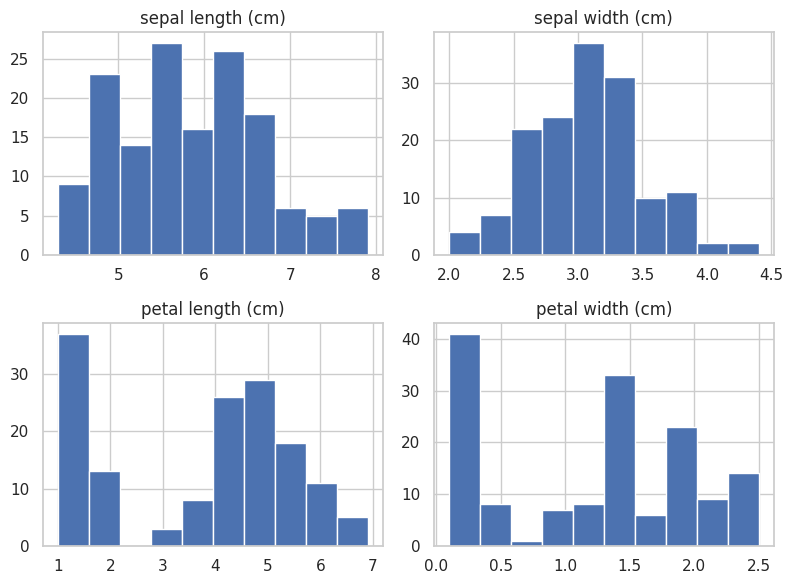

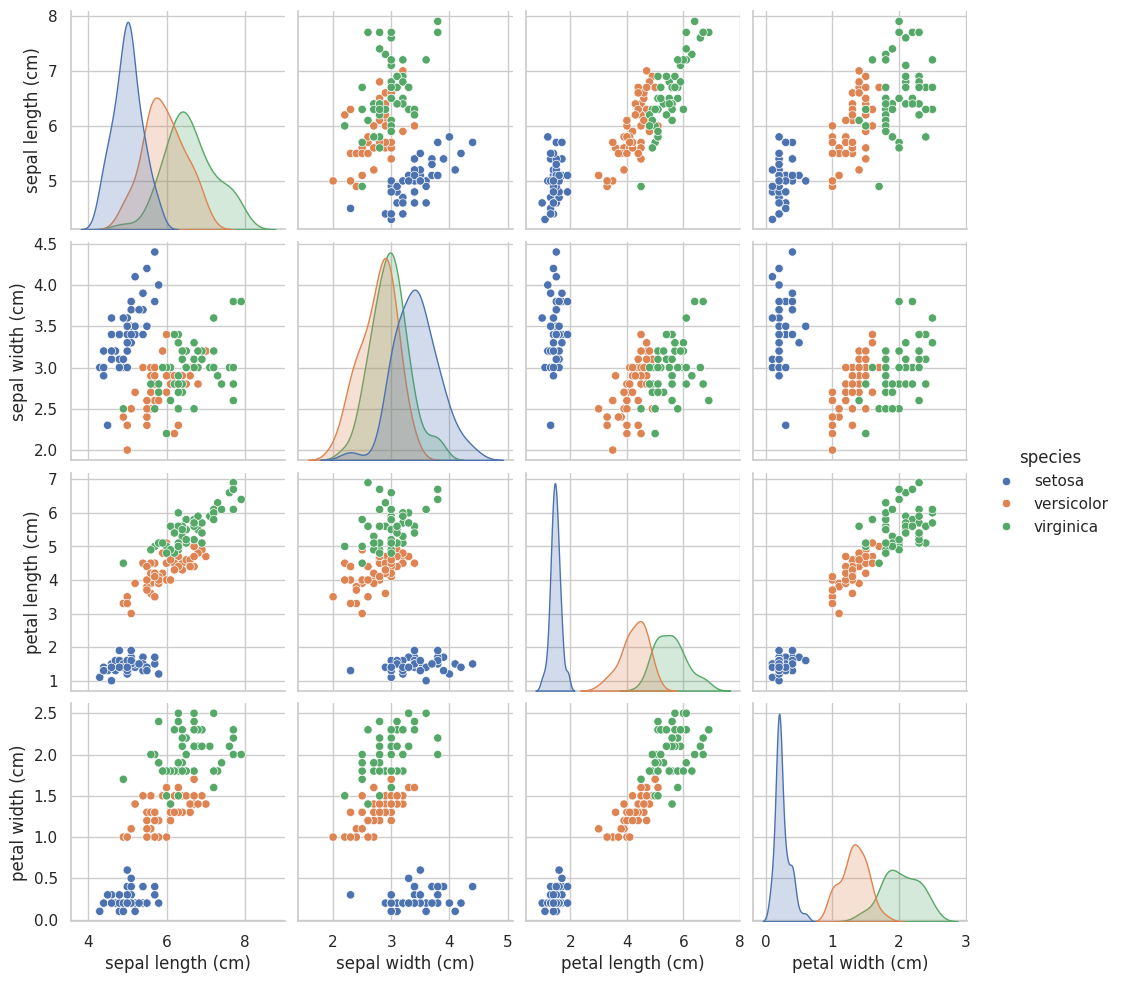

In [3]:
df[feature_names].hist(figsize=(8,6))
plt.tight_layout()
plt.show()

sns.pairplot(df, hue="species")
plt.show()

##2. K-Means Clustering

Scaling:

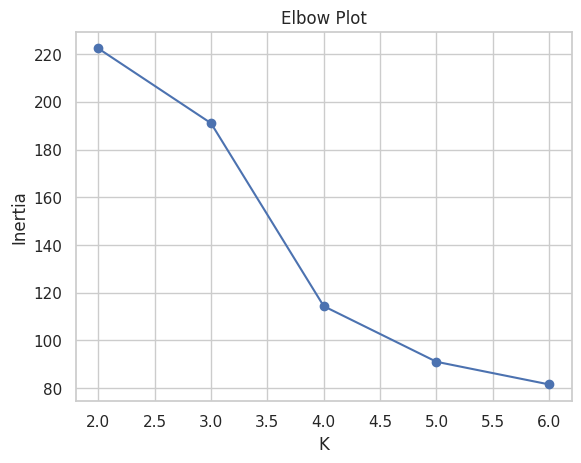

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, adjusted_rand_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
Ks = range(2, 7)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(Ks, inertias, marker="o")
plt.title("Elbow Plot")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

K-Means (k=3) + PCA Visualization:

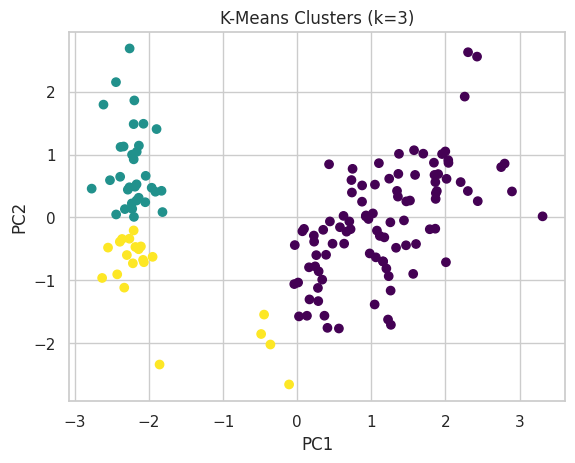

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, cmap="viridis")
plt.title("K-Means Clusters (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Compare to Labels:

In [6]:
cm = confusion_matrix(y, labels_km)
ari = adjusted_rand_score(y, labels_km)

cm, ari

(array([[ 0, 33, 17],
        [46,  0,  4],
        [50,  0,  0]]),
 0.432804702527474)

Interpretations:

I noticed K-Means with k=3 matches the true species nicely and the Setosa species forms a perfect cluster. Increasing K splits natural groups into smaller subclusters.

##3. DBSCAN:

Parameter Sweep:

In [7]:
from sklearn.cluster import DBSCAN

eps_values = [0.3, 0.5, 0.7, 0.9]
min_samples_values = [3, 5, 10]

results = {}

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X_scaled)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = list(labels_db).count(-1)
        results[(eps, ms)] = (n_clusters, n_noise)

results

{(0.3, 3): (10, 84),
 (0.3, 5): (3, 120),
 (0.3, 10): (0, 150),
 (0.5, 3): (7, 17),
 (0.5, 5): (2, 34),
 (0.5, 10): (3, 89),
 (0.7, 3): (2, 5),
 (0.7, 5): (2, 6),
 (0.7, 10): (2, 20),
 (0.9, 3): (2, 4),
 (0.9, 5): (2, 4),
 (0.9, 10): (2, 8)}

Visualization:

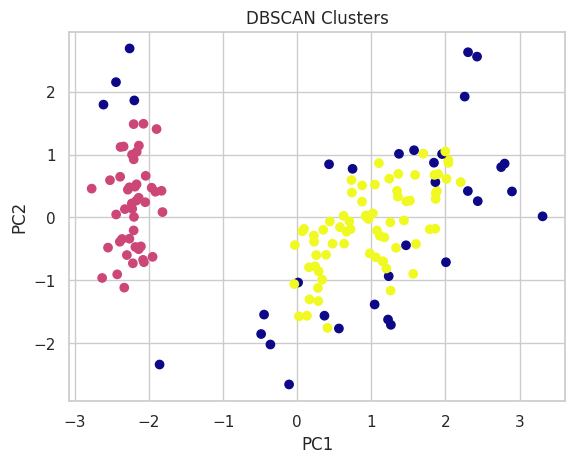

0.4420986685885924

In [8]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, cmap="plasma")
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

adjusted_rand_score(y, labels_db)

Interpretations:

I noticed DBSCAN finds fewer clusters and marks some points as noise. It's not forcing every point into a cluster like K-Means. With the right eps and min_samples, DBSCAN identified dense regions but would merge versicolor and virginica into one cluster. This shows DBSCAN’s strength: it can detect outliers and irregular cluster shapes. However, it’s sensitive to parameter choices, and on a dataset like Iris, DBSCAN can under‑cluster or over‑label noise.

##Reflection

Clustering is everywhere in real-world systems, especially in apps that need to organize large amounts of unstructured data. A great example is modern image management apps like the iPhone photo library that automatically group similar photos together. Instead of relying on users to manually tag or sort thousands of pictures, the app can extract visual features like colors, textures, shapes, or deep-learning embeddings then cluster images that share similar patterns. This allows the app to automatically create collections like “dogs,” “sunsets,” “screenshots,” or “food,” making it way easier for people to find what they’re looking for. Clustering transforms a chaotic photo library into an organized, searchable experience without requiring any labels.

While clustering is powerful, it also comes with important ethical and societal considerations. Because clustering is unsupervised, the groups it creates aren’t always obvious or transparent, and users usually have no idea how or why they were placed into a certain cluster. If the data contains sensitive attributes, even indirectly, the algorithm might unintentionally group people in ways that reflect or amplify bias. For example, clustering user photos or behavior could reveal private patterns that people didn’t intend to share, raising privacy concerns. And if companies use these clusters for decisions like targeted advertising, pricing, or risk assessment, certain groups could be treated unfairly without ever knowing why. Responsible use of clustering requires transparency, careful handling of personal data, and awareness of how algorithmic grouping can impact real people.